In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data', header=None)
lista = ['comprimento_sepala', 'largura_sepala', 'comprimento_petala', 'largura_petala', 'classe']
df.columns = lista

df.head(5)

,comprimento_sepala,largura_sepala,comprimento_petala,largura_petala,classe
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
classe = df [ 'classe'].unique()

In [4]:
entrada = df.iloc[:, 0:4].values
saida = df.iloc[:, 4].values

In [5]:
df.iloc[:, 4].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [6]:
dados_treino, dados_teste, saida_treino, saida_teste = train_test_split(entrada, saida, test_size=0.2)

In [7]:
sc = StandardScaler()
sc.fit(dados_treino)
dados_treino_padronizados = sc.transform(dados_treino)
dados_teste_pradronizado = sc.transform(dados_teste)
saida_treino_onehot = pd.get_dummies(saida_treino).values
saida_teste_onehot = pd.get_dummies(saida_teste).values

In [8]:
modelo = tf.keras.models.Sequential()
modelo.add(tf.keras.layers.Dense(64, input_dim=4, activation='sigmoid', name='oculta'))
modelo.add(tf.keras.layers.Dense(3, activation='softmax', name='camada_saida'))

modelo.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ oculta (Dense)                  │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ camada_saida (Dense)            │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 515 (2.01 KB)

 Trainable params: 515 (2.01 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
opt = tf.keras.optimizers.Adam(learning_rate=0.01)
modelo.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])


In [10]:
history = modelo.fit(dados_treino, saida_treino_onehot, validation_split=0.2, epochs=100, batch_size=10)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.4271 - loss: 1.1265 - val_accuracy: 0.5833 - val_loss: 0.9875
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6979 - loss: 0.8321 - val_accuracy: 0.7500 - val_loss: 0.7173
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6562 - loss: 0.7209 - val_accuracy: 0.5833 - val_loss: 0.6421
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8229 - loss: 0.5782 - val_accuracy: 0.8333 - val_loss: 0.4988
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8021 - loss: 0.5058 - val_accuracy: 0.8750 - val_loss: 0.4702
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9167 - loss: 0.4381 - val_accuracy: 0.9583 - val_loss: 0.3990
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9479 - loss: 0.3968 - val_accuracy: 1.0000 - val_loss: 0.3709
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9583 - loss: 0.3481 - val_accuracy: 1.

/tmp/ipykernel_1014/3219601374.py:6: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend('Treino', 'Teste', loc='upper left')


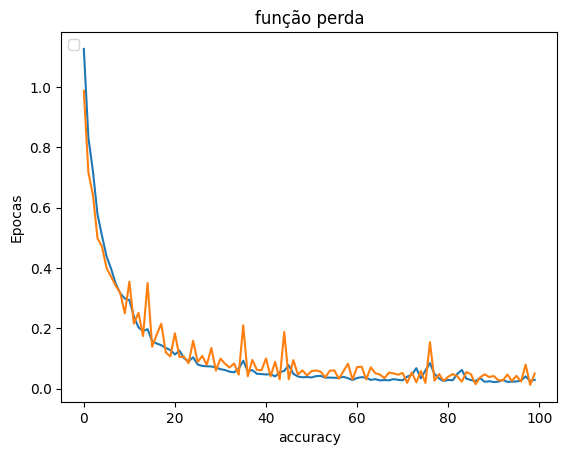

In [11]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('função perda')
plt.xlabel('accuracy')
plt.ylabel('Epocas')
plt.legend('Treino', 'Teste', loc='upper left')
plt.show()

In [13]:
teste = np.array([[5.1, 3.5, 1.4, 0.2]])
teste = sc.transform(teste)
y_predd = modelo.predict(teste)
y_predd =np.argmax(y_predd, axis=1)+1
print("A classe é:", y_predd[-1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
A classe é: 1
